# Aufgabe 1

Bei der ersten Aufgabe sollten wir das Beugungsbild vom Einzelspalt messen. Mithilfe des Beugungsbildes können wir dann die Spaltbreite bestimmen und mit den echten Werten vergleichen. Wir haben 4 Messungen gemacht mit verschiedenen Spaltbreiten: 0,2mm; 0,4mm; 0,8mm und 1,6mm. Wir nutzen zwei verfahren für die bestimmung der Spaltbreite, zum einen über den Abstand vom Hauptmaxima zum Minimum erster Ordnung und zum anderen mithilfe der Fouriertransformation.

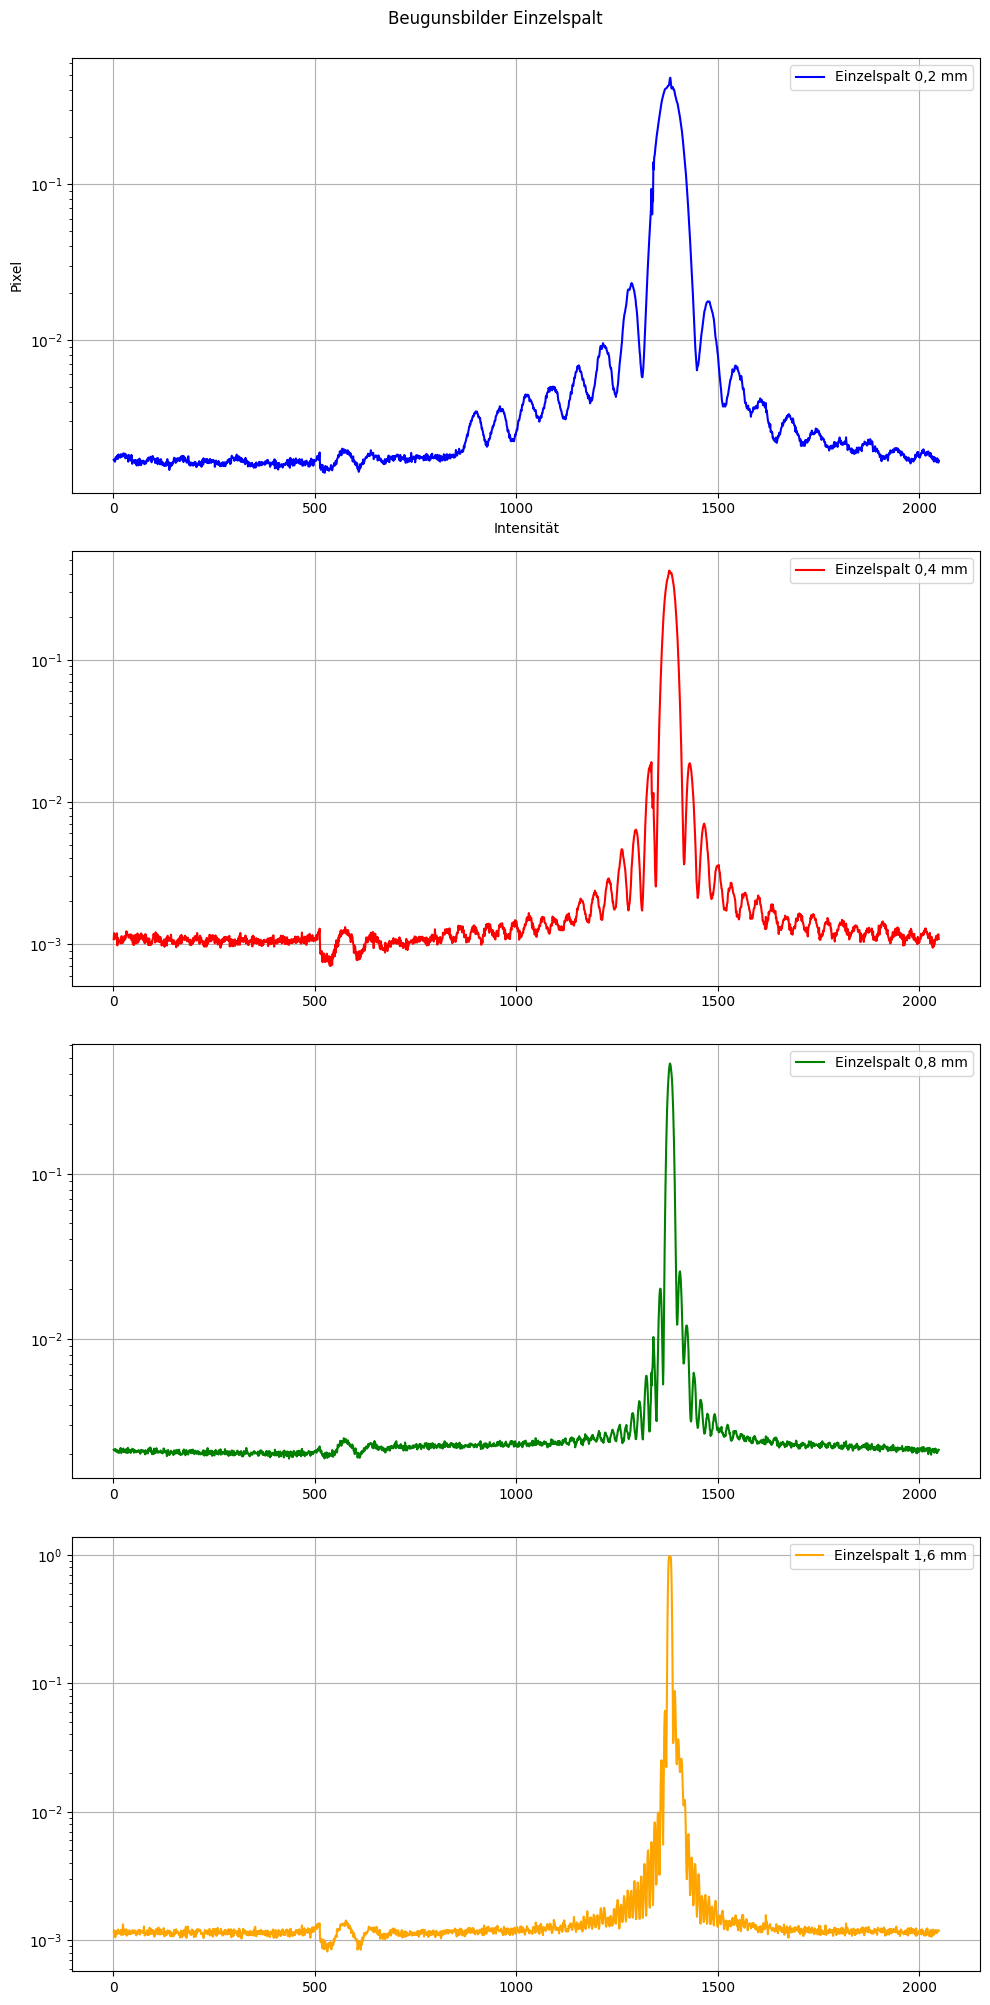

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv")
dt = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv")
dn = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv")
dm = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv")


# Plot für a_x
fig, axs = plt.subplots(4, 1, figsize=(10, 20))
fig.suptitle("Beugunsbilder Einzelspalt", y=1)

axs[0].plot(df['x'], df['y'], label="Einzelspalt 0,2 mm", color="blue")
axs[0].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(dt['x'], dt['y'], label="Einzelspalt 0,4 mm", color="red")
axs[1].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(dn['x'], dn['y'], label="Einzelspalt 0,8 mm", color="green")
axs[2].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[2].grid(True)
axs[2].legend()

axs[3].plot(dm['x'], dm['y'], label="Einzelspalt 1,6 mm", color="orange")
axs[3].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[3].grid(True)
axs[3].legend()

fig.tight_layout()
plt.show()

## Bestimmung der Spaltbreite mithilfe der Minima erster Ordnung

Da wir aus dem aufgenommenen Beugungsmuster auslesen können, wie viele pixel zwischen dem Maxima 0. Ordnung und den ersten Minima in beiden Richtungen liegen, können wir durch die Pixelgröße den Realabstand berechnen. Dadurch kann dann auf die Spaltbreite geschlossen werden. D. h. wir haben nehmen die pixelposition vom Maximum nullter Ordnung und die beiden ersten Minima und suche den Pixelabstand. Dann nehmen wir den Durchschnitt von den beiden und multiplizieren ihn mit der realen größe eines Pixels. Dieser war im Fall unseres Experiments 11 $\mu m$. Jetzt brauchen wir nur noch eine Formel um aus dem Abstand zum ersten Minimum die Spaltbreite zu berechnen. Dafür nutzen wir die Formel die beim Einzelspalt gilt:
$$sin(\alpha) \cdot b = n \cdot \lambda$$
Hierbei ist $n$ die Ordnungszahl des Minimums, $b$ die Spaltbreite, $\lambda$ die Wellenlänge und $\alpha$ der Winkel der n-ten Beugungsordnung. Bei unserem Aufbau sitzt die Kamera in der Brennweite von der Sammellinse und dabei gilt für kleine Winkel:
$$tan(\alpha) \approx sin(\alpha) \approx \frac{x}{f} \implies b \approx \frac{\lambda \cdot f}{x}$$
Hierbei ist x der Abstand auf der Kamera und f die Brennweite. Die Brennweite haben wir gegeben mit 308 mm und die Wellenlänge des genutzten Diodenlasers war 636 nm. Jetzt können wir die Spaltbreite mithilfe unseres Beugungsmusters berechnen. Da beim 1,6 mm Spalt das Minima erster Ordnung sehr schlecht abzulesen ist, haben wir nur die ersten 3 genutzt.


=== Auswertung für Einzelspalt-Daten 1 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1380.0 px
Pixelposition 1. Minimum links     : 1312.0 px
Pixelposition 1. Minimum rechts    : 1450.0 px
Delta_px links                     : 68.0 px
Delta_px rechts                    : 70.0 px
gemitteltes Delta_px               : 69.0 px
Abstand                            : 7.590e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 2.581e-04 m
                                   = 258.09 µm
-------------------------------------------------
Pixelabweichung:  5.281  pixel


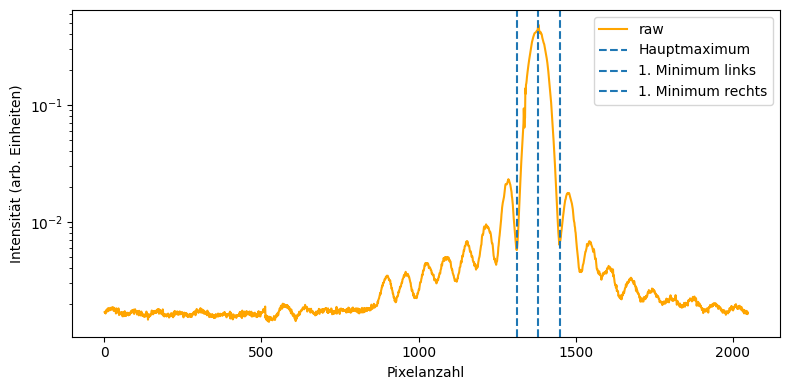


=== Auswertung für Einzelspalt-Daten 2 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1381.0 px
Pixelposition 1. Minimum links     : 1346.0 px
Pixelposition 1. Minimum rechts    : 1417.0 px
Delta_px links                     : 35.0 px
Delta_px rechts                    : 36.0 px
gemitteltes Delta_px               : 35.5 px
Abstand                            : 3.905e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 5.016e-04 m
                                   = 501.63 µm
-------------------------------------------------
Pixelabweichung:  9.239  pixel


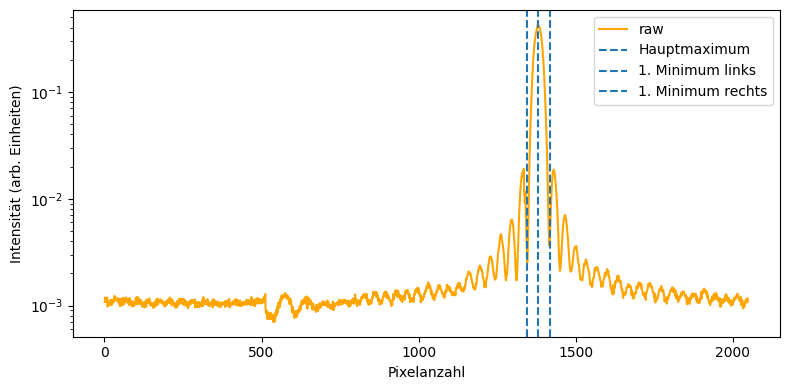


=== Auswertung für Einzelspalt-Daten 3 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1382.0 px
Pixelposition 1. Minimum links     : 1363.0 px
Pixelposition 1. Minimum rechts    : 1400.0 px
Delta_px links                     : 19.0 px
Delta_px rechts                    : 18.0 px
gemitteltes Delta_px               : 18.5 px
Abstand                            : 2.035e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 9.626e-04 m
                                   = 962.59 µm
-------------------------------------------------
Pixelabweichung:  14.781  pixel


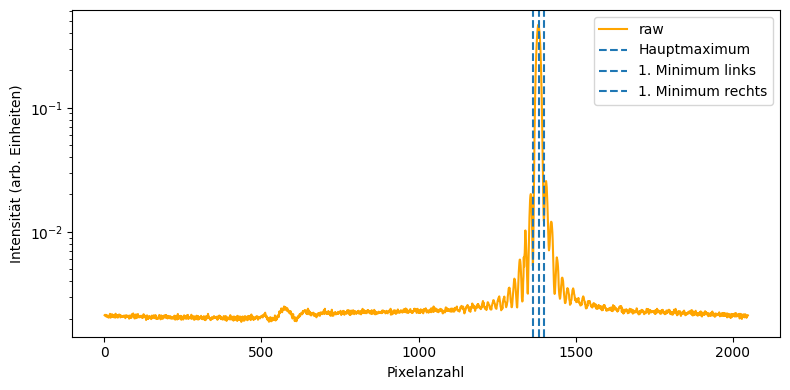

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------------------------------------------
# 1) EXPERIMENTPARAMETER
# ---------------------------------------------------
lambda_ = 636e-9      # Wellenlänge in m (636 nm)
f = 0.308           # Brennweite der Linse in m -> HIER euren Wert eintragen!
pixel_size = 11e-6     # Pixelgröße in m (z.B. 7 µm)

einzelspalt_0_2 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv"
einzelspalt_0_4 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv"
einzelspalt_0_8 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv"
einzelspalt_1_6 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv"

spalte = [2, 4, 8]
# ---------------------------------------------------
# 2) Daten einlesen
# ---------------------------------------------------
df_1 = pd.read_csv(einzelspalt_0_2)
df_2 = pd.read_csv(einzelspalt_0_4)
df_3 = pd.read_csv(einzelspalt_0_8)
for i, df in enumerate([df_1, df_2, df_3], start=1):
    print(f"\n=== Auswertung für Einzelspalt-Daten {i} ===")
    x_pixels = df["x"].values          # Pixelindizes (1..N)
    I_raw = df["y"].values.astype(float)

    # ---------------------------------------------------
    # 3) Intensität leicht glätten
    # ---------------------------------------------------
    window = 7
    kernel = np.ones(window) / window
    I = np.convolve(I_raw, kernel, mode="same")

    # ---------------------------------------------------
    # 4) Hauptmaximum finden
    # ---------------------------------------------------
    peaks, _ = find_peaks(I)
    idx_max_main = peaks[np.argmax(I[peaks])]   # Index des höchsten Peaks
    x0_px = x_pixels[idx_max_main]              # Pixelposition des Hauptmaximums

    # ---------------------------------------------------
    # 5) Minima 1. Ordnung links und rechts vom Hauptmaximum
    #    -> Minima sind Peaks in -I
    # ---------------------------------------------------
    minima_idx, _ = find_peaks(-I)

    # Minima links/rechts vom Hauptmaximum
    minima_left = minima_idx[minima_idx < idx_max_main]
    minima_right = minima_idx[minima_idx > idx_max_main]

    # nächstgelegenes Minimum links/rechts = 1. Ordnung
    idx_min_left = minima_left[-1]    # größter Index < idx_max_main
    idx_min_right = minima_right[0]   # kleinster Index > idx_max_main

    x_left_px = x_pixels[idx_min_left]
    x_right_px = x_pixels[idx_min_right]

    # Pixelabstände vom Hauptmaximum
    delta_px_left = abs(x_left_px - x0_px)
    delta_px_right = abs(x_right_px - x0_px)

    # x1 als Mittelwert der beiden Seiten (sollten ideal gleich sein)
    delta_px = 0.5 * (delta_px_left + delta_px_right)
    x1_phys = delta_px * pixel_size   # Abstand 1. Minimum in Metern

    # ---------------------------------------------------
    # 6) Spaltbreite b aus Fraunhofer-Bedingung
    #    b * sin(alpha_1) = lambda,  sin(alpha_1) ≈ x1 / f
    #    -> b = lambda * f / x1
    # ---------------------------------------------------
    b = lambda_ * f / x1_phys
    pixelabweichung = (b*1e6 - spalte[i-1]*1e2)/(pixel_size*1e6)

    print("-------------------------------------------------")
    print(f"Pixelposition Hauptmaximum         : {x0_px:.1f} px")
    print(f"Pixelposition 1. Minimum links     : {x_left_px:.1f} px")
    print(f"Pixelposition 1. Minimum rechts    : {x_right_px:.1f} px")
    print(f"Delta_px links                     : {delta_px_left:.1f} px")
    print(f"Delta_px rechts                    : {delta_px_right:.1f} px")
    print(f"gemitteltes Delta_px               : {delta_px:.1f} px")
    print(f"Abstand                            : {x1_phys:.3e} m")
    print("-------------------------------------------------")
    print(f"Spaltbreite b (nur 1. Ordnung)     : {b:.3e} m")
    print(f"                                   = {b*1e6:.2f} µm")
    print("-------------------------------------------------")
    print(f"Pixelabweichung:  {pixelabweichung:.3f}  pixel")
    # ---------------------------------------------------
    # 7) Plot zur Kontrolle
    # ---------------------------------------------------
    # x-Achse um das Hauptmaximum zentrieren (in mm)
    x_rel_m = (x_pixels - x0_px) * pixel_size

    plt.figure(figsize=(8,4))
    plt.plot(x_pixels, I_raw, label="raw", color="orange")
    #plt.plot(x_rel_m * 1e3, I, label="smoothed", alpha=0.7)

    plt.axvline(x0_px, linestyle="--", label="Hauptmaximum")
    plt.axvline(x_left_px, linestyle="--", label="1. Minimum links")
    plt.axvline(x_right_px, linestyle="--", label="1. Minimum rechts")

    plt.yscale("log")
    plt.xlabel("Pixelanzahl")
    plt.ylabel("Intensität (arb. Einheiten)")
    plt.legend()
    plt.tight_layout()
    plt.show()


| Ursprüngliche Spaltbreite (b_{\text{soll}}) | Berechnete Spaltbreite (b_{\text{ist}}) | Prozentuale Abweichung |
| ------------------------------------------- | --------------------------------------- | ---------------------- |
| 0,2 mm (200 µm)                             | 258,09 µm                               | 29,05 %                |
| 0,4 mm (400 µm)                             | 501,63 µm                               | 25,41 %                |
| 0,8 mm (800 µm)                             | 962,59 µm                               | 20,32 %                |


### Aufgabe 1b: Bestimmung der Spaltbreite mit Hilfe der Fouriertransformation

#### Ziel

In diesem Aufgabenteil soll die Spaltbreite $b$ nicht wie in 1a über die Position der Minima im Beugungsbild bestimmt werden, sondern über eine numerische Fouriertransformation der gemessenen Intensitätsverteilung. Aus dem Frequenzspektrum rekonstruieren wir die Ausdehnung des Spalts im Ortsraum.

#### Theoretischer Hintergrund

Ein idealer Einzelspalt der Breite $b$ habe im Spaltkoordinatenraum die Transmission

$$
A(x) =
\begin{cases}
1, & |x| \le \frac{b}{2} \\
0, & \text{sonst}
\end{cases}
$$

Die Fraunhoferbeugung am Einzelspalt liefert für die Feldamplitude in der Fernzone eine sinc Funktion. Die Intensität im Fernfeld (z.B. auf der CCD Kamera) hat die Form
$I(x) \propto \text{sinc}^2\!\left(\frac{\pi b x}{\lambda f}\right)$, wobei die Variablen genau wie in a) vergeben sind. Die Fouriertransformation der Intensität $I(x)$ besitzt eine besondere Eigenschaft, sie ist proportional zur Autokorrelationsfunktion des Spalts. Die Autokorrelation einer Rechteckfunktion ergibt eine Dreiecksform mit Basisbreite $2b$. Aus der Breite dieser Dreiecksform können wir also direkt auf $b$ schließen.
#### Vorgehensweise

1. **Einlesen und Zentrieren der Daten**  
   - Einlesen der Messdaten $I(x_\text{pixel})$ aus den CSV Dateien.  
   - Umrechnung von Pixelnummern in Kamerakoordinate  
     $x = (x_\text{pixel} - x_{0,\text{pixel}})\cdot \text{pixel\_size}$
     wobei $x_{0,\text{pixel}}$ die Position des Hauptmaximums ist.

2. **Übergang von Kamerakoordinate zu Raumfrequenz**  
   Im Linsen Fraunhoferaufbau gilt für kleine Winkel
   $\sin\alpha \approx \frac{x}{f}$
   $\quad\Rightarrow\quad$
   $\kappa = \frac{\sin\alpha}{\lambda} \approx \frac{x}{\lambda f}$
   Wir definieren also eine gleichabständige Raumfrequenzachse
   $\kappa_i = \frac{x_i}{\lambda f}$


3. **Numerische Fouriertransformation**  
   - Wir berechnen die diskrete Fouriertransformation der gemessenen Intensität $I(\kappa)$ mit `numpy.fft.fft`.  
   - Die transformierte Funktion $G(x') = \mathcal{F}\{I(\kappa)\}$ wird gegen eine neue Variable $x'$ aufgetragen, die wieder eine Ortskoordinate in der Spaltebene repräsentiert (Autokorrelation des Spalts).

4. **Normierung und Glättung**  
   - Wir betrachten den Betrag $|G(x')|$ und normieren ihn auf 1 im Maximum.  
   - Zur Rauschunterdrückung wird $|G(x')|$ zusätzlich mit einem gleitenden Mittelwert geglättet.

5. **Bestimmung der Basisbreite der Dreiecksform**  
   - Wir bestimmen die Position des Maximums von $|G(x')|$.  
   - Anschliessend suchen wir auf der linken und rechten Seite die Stellen, an denen $|G(x')|$ unter einen kleinen Schwellwert (z.B. 5 Prozent des Maximums) fällt. Diese Punkte approximieren die Nullstellen der Dreiecksform.  
   - Die Differenz der beiden Positionen
     \[
     \Delta x' \approx 2b
     \]
     entspricht näherungsweise der Basisbreite der Dreiecksform.

6. **Berechnung der Spaltbreite**  
   Aus der gemessenen Breite $\Delta x'$ ergibt sich die Spaltbreite zu
   $b \approx \frac{\Delta x'}{2}$
   Dieser Wert wird für die verschiedenen Nennspaltbreiten (0,2 mm, 0,4 mm, 0,8 mm) bestimmt und mit den Herstellerangaben verglichen.


Einzelspalt 0.2 mm
--------------------------------------------
Pixelposition Hauptmaximum : 1380.0 px
x'_links  (ca. -b)         : -286.9 µm
x'_rechts (ca. +b)         : 286.9 µm
Breite 2b (FFT)            : 573.9 µm
Spaltbreite b (FFT)        : 2.869e-04 m = 286.9 µm



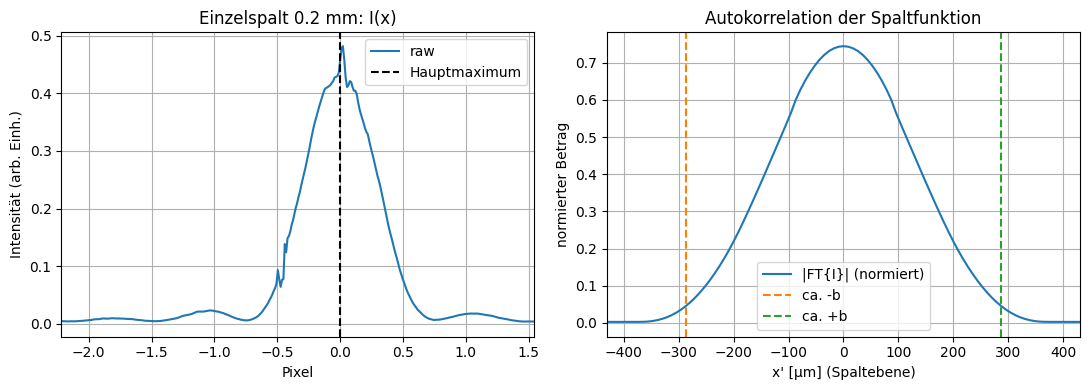

Einzelspalt 0.4 mm
--------------------------------------------
Pixelposition Hauptmaximum : 1381.0 px
x'_links  (ca. -b)         : -504.3 µm
x'_rechts (ca. +b)         : 504.3 µm
Breite 2b (FFT)            : 1008.7 µm
Spaltbreite b (FFT)        : 5.043e-04 m = 504.3 µm



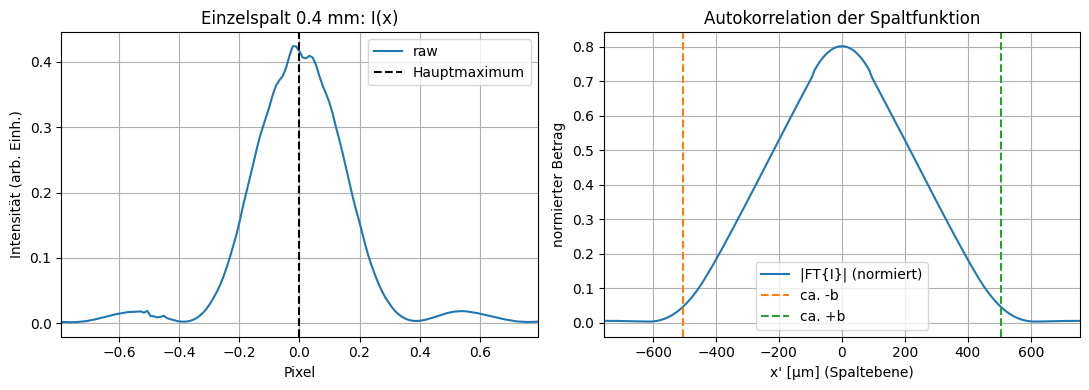

Einzelspalt 0.8 mm
--------------------------------------------
Pixelposition Hauptmaximum : 1382.0 px
x'_links  (ca. -b)         : -939.1 µm
x'_rechts (ca. +b)         : 939.1 µm
Breite 2b (FFT)            : 1878.2 µm
Spaltbreite b (FFT)        : 9.391e-04 m = 939.1 µm



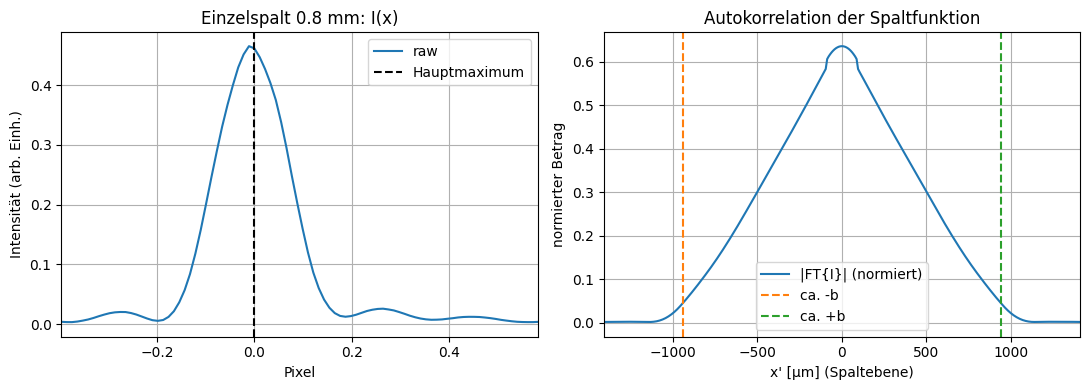

Zusammenfassung b (FFT Methode):
0.2 mm: b_FFT = 286.9 µm
0.4 mm: b_FFT = 504.3 µm
0.8 mm: b_FFT = 939.1 µm


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1) Parameter
lambda_ = 636e-9      # Wellenlänge in m
f       = 0.308       # Brennweite der Linse in m
pixel_size = 11e-6     # Pixelgröße in m

files = [
    ("0.2 mm", "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv"),
    ("0.4 mm", "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv"),
    ("0.8 mm", "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv"),
]

def slit_width_from_fft(csv_path, label, plot=True):
    # 2) Daten einlesen
    df = pd.read_csv(csv_path)
    x_pixels = df["x"].values
    I_raw    = df["y"].values.astype(float)

    # leichte Glättung
    window = 7
    kernel = np.ones(window) / window
    I = np.convolve(I_raw, kernel, mode="same")

    # 3) Hauptmaximum finden
    peaks, _ = find_peaks(I)
    idx_max_main = peaks[np.argmax(I[peaks])]
    x0_px = x_pixels[idx_max_main]

    # Pixel -> Kamerakoordinate (relativ zum Hauptmaximum)
    x_rel_px = x_pixels - x0_px
    x_cam = x_rel_px * pixel_size        # in m, x=0 am Hauptmaximum

    # 4) x -> kappa = x / (lambda * f)
    kappa = x_cam / (lambda_ * f)
    d_kappa = np.mean(np.diff(kappa))

    # 5) FFT in kappa
    I_k = I
    G = np.fft.fft(I_k) * d_kappa
    x_prime = np.fft.fftfreq(len(I_k), d=d_kappa)
    G_shift = np.fft.fftshift(G)
    x_prime_shift = np.fft.fftshift(x_prime)

    mag = np.abs(G_shift)
    mag /= mag.max()

    # glätten im x'-Raum
    win_ft = 21
    kernel_ft = np.ones(win_ft) / win_ft
    mag_smooth = np.convolve(mag, kernel_ft, mode="same")

    # 6) Dreiecksbreite bestimmen
    center = np.argmax(mag_smooth)
    idx = np.arange(len(mag_smooth))
    thr = 0.05   # 5 % Schwelle

    right_idx = np.where((idx > center) & (mag_smooth < thr))[0][0]
    left_idx  = np.where((idx < center) & (mag_smooth < thr))[0][-1]

    x_left  = x_prime_shift[left_idx]
    x_right = x_prime_shift[right_idx]

    width_support = x_right - x_left    # ca. 2b
    b_est = width_support / 2.0

    print("============================================")
    print(f"Einzelspalt {label}")
    print("--------------------------------------------")
    print(f"Pixelposition Hauptmaximum : {x0_px:.1f} px")
    print(f"x'_links  (ca. -b)         : {x_left*1e6:.1f} µm")
    print(f"x'_rechts (ca. +b)         : {x_right*1e6:.1f} µm")
    print(f"Breite 2b (FFT)            : {width_support*1e6:.1f} µm")
    print(f"Spaltbreite b (FFT)        : {b_est:.3e} m = {b_est*1e6:.1f} µm")
    print("============================================\n")

    # 7) Plots mit Zoom
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        # (a) Beugungsbild in Kamerabene
        axes[0].plot(x_cam * 1e3, I_raw, label="raw")
        #axes[0].plot(x_cam * 1e3, I,     label="smoothed", alpha=0.7)
        axes[0].axvline(0.0, linestyle="--", color="k", label="Hauptmaximum")
        axes[0].set_xlabel("Pixel")
        axes[0].set_ylabel("Intensität (arb. Einh.)")
        axes[0].set_title(f"Einzelspalt {label}: I(x)")
        axes[0].legend()
        axes[0].grid(True)

        # Zoom im Kameraplot: nur Bereich, wo I signifikant ist
        mask_cam = I > 0.02 * I.max()   # alles ueber 2 % vom Maximum
        if np.any(mask_cam):
            x_min_cam = x_cam[mask_cam].min()
            x_max_cam = x_cam[mask_cam].max()
            margin = 1.2
            axes[0].set_xlim(x_min_cam*1e3*margin, x_max_cam*1e3*margin)

        # (b) Betrag der Fouriertransformierten |FT{I}|
        axes[1].plot(x_prime_shift * 1e6, mag_smooth, label="|FT{I}| (normiert)")
        axes[1].axvline(x_left * 1e6,  linestyle="--", color="C1", label="ca. -b")
        axes[1].axvline(x_right * 1e6, linestyle="--", color="C2", label="ca. +b")
        axes[1].set_xlabel("x' [µm] (Spaltebene)")
        axes[1].set_ylabel("normierter Betrag")
        axes[1].set_title("Autokorrelation der Spaltfunktion")
        axes[1].legend()
        axes[1].grid(True)

        # Zoom im FFT Plot: nur Bereich um -b bis +b mit etwas Rand
        margin_fft = 1.5
        x_min_fft = x_left * margin_fft
        x_max_fft = x_right * margin_fft
        axes[1].set_xlim(x_min_fft*1e6, x_max_fft*1e6)

        plt.tight_layout()
        plt.show()

    return b_est


# alle Dateien auswerten
b_fft_results = []
for label, path in files:
    b_est = slit_width_from_fft(path, label, plot=True)
    b_fft_results.append((label, b_est))

print("Zusammenfassung b (FFT Methode):")
for label, b_est in b_fft_results:
    print(f"{label}: b_FFT = {b_est*1e6:.1f} µm")
